# Credit Card Customer Profiling & Banking Strategy

**A compact, end-to-end customer analytics project combining supervised learning (high-value customer prediction) and unsupervised learning (customer segmentation) on a real-world bank credit card portfolio.**

---

## Business Problem

A retail bank's credit card division wants to answer three questions about its ~10,000-customer portfolio:

1. **Which customers are high-value today**, and can that status be predicted from demographic and behavioral signals the bank already collects?
2. **What natural customer segments exist** in the portfolio, without relying on any predefined label?
3. **How should the bank act on these insights** — what offers, retention tactics, or cross-sell strategies fit each type of customer?

This notebook walks through the full pipeline end-to-end:

`Business Problem → Data → EDA → Target Engineering → Model Comparison → Tuning → Pipeline → Segmentation → PCA → Customer Personas → Banking Strategy → Executive Summary`

## Dataset

**Source:** [Credit Card Customers](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers) (`BankChurners.csv`) on Kaggle — a real, anonymized portfolio of **10,127 bank credit card customers** with demographic, relationship, and transaction-behavior attributes. This is not a synthetic/toy dataset; it originates from a real credit card attrition study and is one of the most widely used real-world banking datasets on Kaggle.


In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)


## 1. Data Loading

We load the dataset the way Kaggle's `kagglehub` API recommends. If `kagglehub` isn't authenticated in the current environment (e.g. no Kaggle API token configured), we fall back to a local copy in `data/BankChurners.csv` — the exact same file, just cached for reproducibility so this notebook always runs end-to-end.

In [6]:
def load_data():
    '''Load BankChurners.csv via kagglehub (preferred), falling back to a local cached copy.'''
    try:
        import kagglehub
        from kagglehub import KaggleDatasetAdapter

        data = kagglehub.load_dataset(
            KaggleDatasetAdapter.PANDAS,
            "sakshigoyal7/credit-card-customers",
            "BankChurners.csv",
        )
        print("Loaded dataset via kagglehub (latest version from Kaggle).")
        return data
    except Exception as e:
        print(f"kagglehub unavailable ({type(e).__name__}); loading local cached copy instead.")
        return pd.read_csv("../data/BankChurners.csv")


df_raw = load_data()
print("Shape:", df_raw.shape)
df_raw.head()


kagglehub unavailable (ValueError); loading local cached copy instead.


FileNotFoundError: [Errno 2] No such file or directory: '../data/BankChurners.csv'

## 2. Data Cleaning

Three things need handling before any analysis:

1. **Two "leaked" columns.** The dataset ships with two pre-computed Naive Bayes classifier probability columns (`Naive_Bayes_Classifier_...`) that the dataset's own documentation warns should be dropped — they were accidentally included by the original data provider and are not legitimate features.
2. **Missing values & duplicates.** Checked explicitly below.
3. **`CLIENTNUM`** is a unique row identifier — dropped later before modeling (it carries no signal, and used naively could function as a leakage-prone unique key).

Note: some categorical columns (`Education_Level`, `Marital_Status`, `Income_Category`) contain the literal string `"Unknown"`. We treat this as its own valid category rather than a missing value — the bank genuinely doesn't have this data point on file for these customers, and that "unknown" status is itself potentially informative (e.g. correlated with how a customer was onboarded).

In [3]:
df = df_raw.copy()

# Drop the two leaked Naive-Bayes probability columns (documented issue with this dataset)
leaked_nb_cols = [c for c in df.columns if c.startswith("Naive_Bayes_Classifier")]
df = df.drop(columns=leaked_nb_cols)

print(f"Dropped {len(leaked_nb_cols)} leaked Naive-Bayes columns.")
print("Missing values per column:\n", df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else "None")
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate CLIENTNUM values:", df['CLIENTNUM'].duplicated().sum())
print("\nFinal shape after cleaning:", df.shape)


Dropped 2 leaked Naive-Bayes columns.
Missing values per column:
 None

Duplicate rows: 0
Duplicate CLIENTNUM values: 0

Final shape after cleaning: (10127, 21)


**Result:** the dataset is clean out of the box — **0 missing values** and **0 duplicate rows/customer IDs** once the two leaked columns are removed. This is one of the reasons this dataset is well-suited to a compact, one-day project: no imputation strategy or duplicate-resolution logic is needed, so the day's effort goes into feature engineering, modeling, and business interpretation instead of janitorial data cleaning.

## 3. Exploratory Data Analysis

### 3.1 What the columns mean (business context)

| Column | Business meaning |
|---|---|
| `Customer_Age`, `Gender`, `Dependent_count`, `Education_Level`, `Marital_Status`, `Income_Category` | Demographic profile of the account holder |
| `Card_Category` | Product tier: Blue / Silver / Gold / Platinum |
| `Months_on_book` | Tenure — how long the customer has held the account |
| `Total_Relationship_Count` | Number of bank products the customer holds (cross-sell depth) |
| `Months_Inactive_12_mon` | Inactivity — months with no activity in the trailing 12 months |
| `Contacts_Count_12_mon` | Number of times the customer contacted the bank (service load / friction signal) |
| `Credit_Limit` | Credit line extended — reflects the bank's trust in / underwriting of the customer |
| `Total_Revolving_Bal` | Balance the customer carries month to month (this is what generates **interest revenue** for the bank) |
| `Avg_Open_To_Buy` | Unused credit (`Credit_Limit − Total_Revolving_Bal`) — mathematically derived from `Credit_Limit` |
| `Total_Trans_Amt`, `Total_Trans_Ct` | Total dollar amount and count of transactions in the last 12 months — real usage/spend |
| `Total_Amt_Chng_Q4_Q1`, `Total_Ct_Chng_Q4_Q1` | Spend and transaction-count momentum (Q4 vs Q1 ratio) — is the customer accelerating or decelerating? |
| `Avg_Utilization_Ratio` | `Total_Revolving_Bal / Credit_Limit` — mathematically derived, a classic credit-risk signal |
| `Attrition_Flag` | Whether the customer has already churned (`Attrited Customer`) or is still active (`Existing Customer`) |

Two columns — `Avg_Open_To_Buy` and `Avg_Utilization_Ratio` — are **mathematically derived from `Credit_Limit`** and `Total_Revolving_Bal`. We'll keep this in mind when engineering the target and features later to avoid leakage.

### 3.2 Class balance on the existing label (`Attrition_Flag`)

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Attrition_Flag
Existing Customer    83.93
Attrited Customer    16.07
Name: proportion, dtype: float64


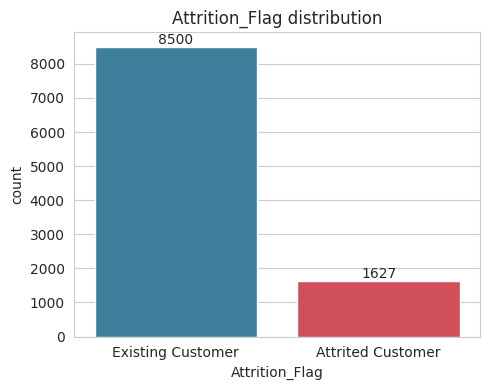

In [4]:
attr_counts = df['Attrition_Flag'].value_counts()
attr_pct = df['Attrition_Flag'].value_counts(normalize=True) * 100
print(attr_counts)
print()
print(attr_pct.round(2))

fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(data=df, x='Attrition_Flag', hue='Attrition_Flag', palette=['#2E86AB','#E63946'], legend=False, ax=ax)
ax.set_title("Attrition_Flag distribution")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()


The portfolio's existing churn base rate is about **16.1% attrited vs. 83.9% existing** — note this is a *different* label from the "High-Value Customer" target we build in Section 4; `Attrition_Flag` tells us who already left, not who is currently valuable.

### 3.3 Key numeric distributions

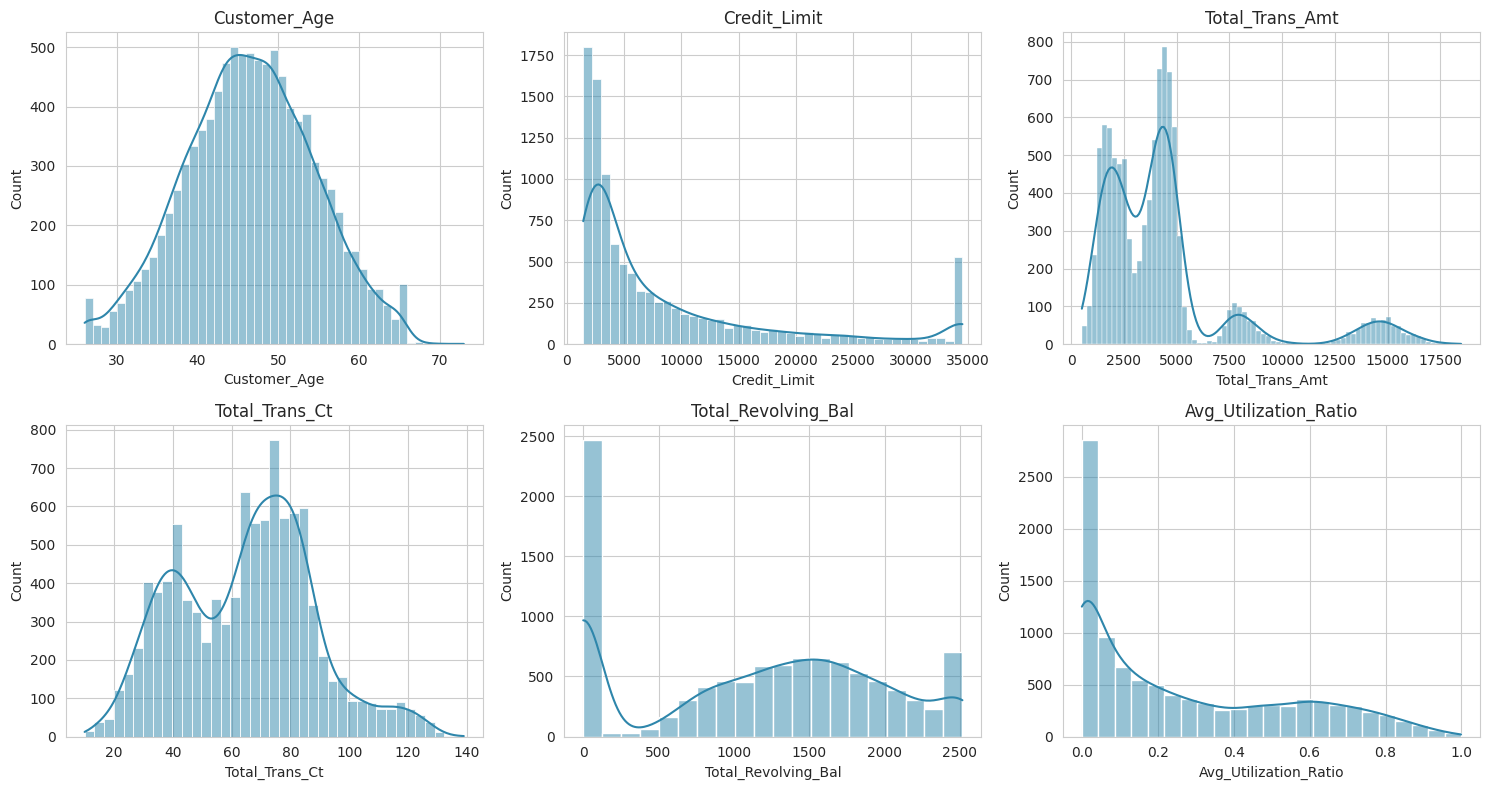

,Customer_Age,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct,Total_Revolving_Bal,Avg_Utilization_Ratio
count,10127.0,10127.0,10127.0,10127.0,10127.0,10127.0
mean,46.3,8632.0,4404.1,64.9,1162.8,0.3
std,8.0,9088.8,3397.1,23.5,815.0,0.3
min,26.0,1438.3,510.0,10.0,0.0,0.0
25%,41.0,2555.0,2155.5,45.0,359.0,0.0
50%,46.0,4549.0,3899.0,67.0,1276.0,0.2
75%,52.0,11067.5,4741.0,81.0,1784.0,0.5
max,73.0,34516.0,18484.0,139.0,2517.0,1.0


In [5]:
num_cols_to_plot = ['Customer_Age','Credit_Limit','Total_Trans_Amt','Total_Trans_Ct','Total_Revolving_Bal','Avg_Utilization_Ratio']

fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax, col in zip(axes.ravel(), num_cols_to_plot):
    sns.histplot(df[col], kde=True, ax=ax, color='#2E86AB')
    ax.set_title(col)
plt.tight_layout()
plt.show()

df[num_cols_to_plot].describe().round(1)


**Reading these distributions:**
- `Credit_Limit` is heavily **right-skewed** — most customers sit under $10K, but a long tail of premium/Platinum customers extends past $30K.
- `Total_Trans_Amt` and `Total_Trans_Ct` are also right-skewed, consistent with a small group of heavy transactors driving disproportionate volume.
- `Avg_Utilization_Ratio` is bimodal-ish, with a large spike near 0 (customers who pay off their balance in full each month — "transactors") and a spread of customers carrying meaningful revolving balances ("revolvers").

### 3.4 Correlation structure among numeric features

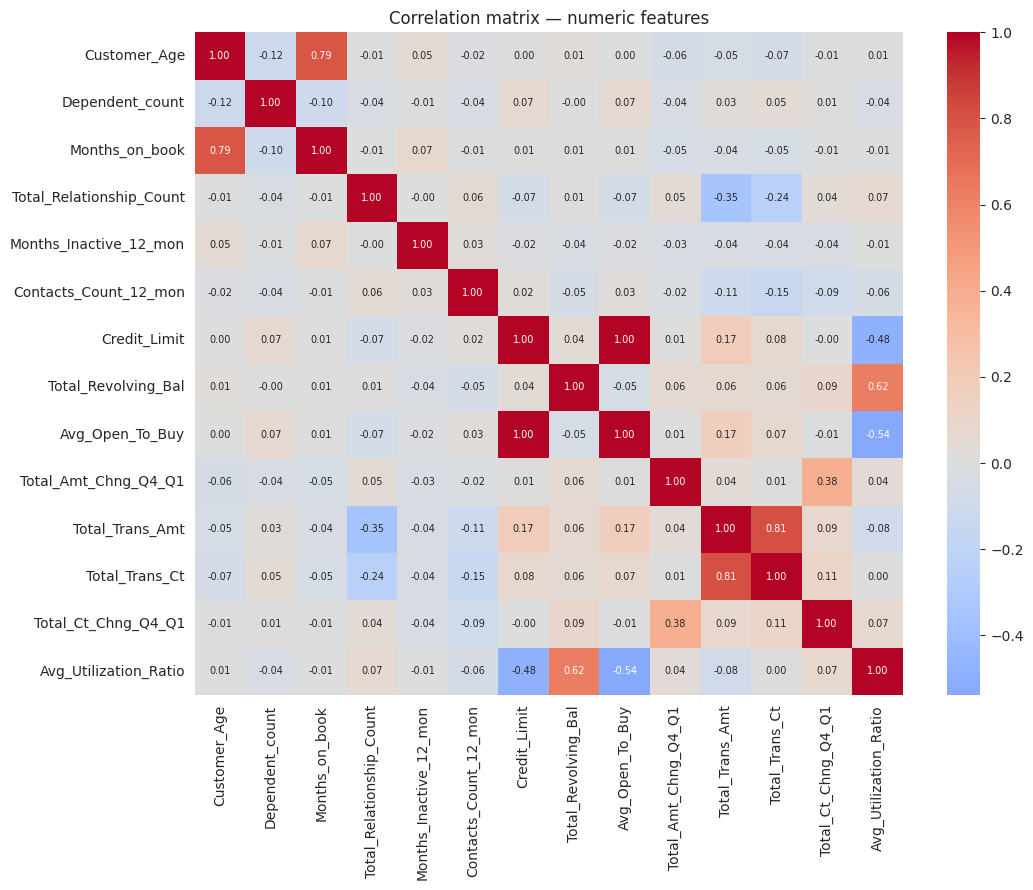

In [6]:
numeric_df = df.select_dtypes(include=np.number).drop(columns=['CLIENTNUM'])
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(11,9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, annot_kws={"size":7})
ax.set_title("Correlation matrix — numeric features")
plt.tight_layout()
plt.show()


Two correlations confirm what we already knew from the data dictionary and matter for leakage-safe modeling later:
- `Avg_Open_To_Buy` correlates almost perfectly with `Credit_Limit` (it's `Credit_Limit − Total_Revolving_Bal`).
- `Avg_Utilization_Ratio` is strongly related to `Total_Revolving_Bal` relative to `Credit_Limit`.

We'll exclude these derived columns from the *feature set* used for the classifier wherever they overlap with how we define the prediction target.

## 4. Defining "High-Value Customer" — the business rule

The raw dataset has **no pre-existing "high value" label** — only `Attrition_Flag` (churn), which answers a different business question. So we engineer a defensible target ourselves.

### Business rule

A credit card customer is valuable to a bank along three independent dimensions:

1. **Lending trust** — `Credit_Limit`: how much the bank is willing to extend, which reflects underwriting confidence and future revenue capacity.
2. **Realized spend** — `Total_Trans_Amt`: actual transaction volume in the last 12 months, which drives **interchange fee revenue**.
3. **Relationship depth** — `Total_Relationship_Count`: how many products the customer holds, a proxy for wallet share and switching cost.

We convert each of these three columns to a **percentile rank** (0–1) across the portfolio, average the three ranks into a single `value_score`, and label the **top quartile (≥ 75th percentile)** of that composite score as `High_Value_Customer = 1`. Averaging percentile ranks (rather than raw dollar values) prevents any single skewed column — e.g. `Credit_Limit`'s long tail — from dominating the composite score.

This produces a clean **~25% positive class**, which is realistic (a bank's "top-tier" segment is usually a minority of the book) and gives us enough positive examples to train on without being so rare that the model has nothing to learn from.

**Leakage guardrail:** because the target is *built directly from* `Credit_Limit`, `Total_Trans_Amt`, and `Total_Relationship_Count`, none of those three columns (nor `Avg_Open_To_Buy` / `Avg_Utilization_Ratio`, which mathematically derive from `Credit_Limit`) can be used as predictive features — including them would let the model trivially reconstruct the label instead of learning genuine behavioral signal. We deliberately train the classifier on demographic and *secondary* behavioral signals (age, tenure, inactivity, contact frequency, transaction **count** and momentum, revolving balance) — the kind of signals a bank could realistically use to flag a customer's value trajectory *before* their credit limit and relationship depth fully reflect it.

In [7]:
for col in ['Credit_Limit', 'Total_Trans_Amt', 'Total_Relationship_Count']:
    df[col + '_pct'] = df[col].rank(pct=True)

df['value_score'] = df[['Credit_Limit_pct', 'Total_Trans_Amt_pct', 'Total_Relationship_Count_pct']].mean(axis=1)
value_threshold = df['value_score'].quantile(0.75)
df['High_Value_Customer'] = (df['value_score'] >= value_threshold).astype(int)

print(f"value_score threshold (75th percentile): {value_threshold:.4f}")
print(df['High_Value_Customer'].value_counts())
print((df['High_Value_Customer'].value_counts(normalize=True) * 100).round(2))

print("\nSanity check — average of the 3 pillar columns by class:")
df.groupby('High_Value_Customer')[['Credit_Limit','Total_Trans_Amt','Total_Relationship_Count']].mean().round(1)


value_score threshold (75th percentile): 0.6063
High_Value_Customer
0    7595
1    2532
Name: count, dtype: int64
High_Value_Customer
0    75.0
1    25.0
Name: proportion, dtype: float64

Sanity check — average of the 3 pillar columns by class:


,Credit_Limit,Total_Trans_Amt,Total_Relationship_Count
High_Value_Customer,,,
0,6013.6,3728.4,3.6
1,16485.9,6430.8,4.5


**2,532 customers (25.0%)** are flagged `High_Value_Customer = 1`. The sanity check confirms the rule behaves as intended: high-value customers average **~$16.5K credit limit vs. ~$6.0K**, **~$6,431 in annual spend vs. ~$3,728**, and **4.5 products vs. 3.6** for the rest of the portfolio.

## 5. Train/test split and leakage-safe feature set

We split **before** touching any preprocessing or modeling (all scaling/encoding happens inside a `Pipeline` fit only on the training fold — see Section 6). We stratify on the target to preserve the 75/25 class balance in both splits.

In [8]:
# Columns excluded from the feature set: ID, the target's own ingredients, and columns
# that mathematically derive from those ingredients (leakage)
leak_and_id_cols = [
    'CLIENTNUM',
    'Credit_Limit', 'Avg_Open_To_Buy', 'Avg_Utilization_Ratio',   # derive from Credit_Limit
    'Total_Trans_Amt',                                             # target ingredient
    'Total_Relationship_Count',                                    # target ingredient
    'Credit_Limit_pct', 'Total_Trans_Amt_pct', 'Total_Relationship_Count_pct', 'value_score',  # scoring scaffolding
]

X = df.drop(columns=leak_and_id_cols + ['High_Value_Customer'])
y = df['High_Value_Customer']

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features   :", numeric_features)
print("Categorical features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"\nTrain: {X_train.shape}, positive rate {y_train.mean():.3f}")
print(f"Test : {X_test.shape}, positive rate {y_test.mean():.3f}")


Numeric features   : ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1']
Categorical features: ['Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

Train: (8101, 15), positive rate 0.250
Test : (2026, 15), positive rate 0.250


## 6. Preprocessing pipeline and baseline model comparison

All preprocessing is wrapped in a single `sklearn.pipeline.Pipeline` fed by a `ColumnTransformer`:

- **Numeric features** → `StandardScaler` (needed for fair distance/gradient-based learning and required later for K-Means/PCA; harmless for tree-based models).
- **Categorical features** → `OneHotEncoder`.

Because scaling/encoding live *inside* the pipeline, `fit()` only ever sees the training fold — there is no leakage of test-set statistics into preprocessing, and the exact same pipeline can be handed a single new customer row at inference time.

We compare three tree-based classifiers with default hyperparameters first, to get an honest baseline before spending any tuning budget:

In [9]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])

baseline_models = {
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

baseline_rows = []
for name, clf in baseline_models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    baseline_rows.append({
        'Model': name,
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
    })

baseline_results = pd.DataFrame(baseline_rows).set_index('Model').round(4)
baseline_results


,Precision,Recall,F1,ROC-AUC
Model,,,,
Decision Tree,0.4417,0.4852,0.4624,0.6402
Random Forest,0.6581,0.4024,0.4994,0.8087
Gradient Boosting,0.6554,0.4576,0.5389,0.8207


**Baseline takeaway:** even before tuning, **Gradient Boosting leads on ROC-AUC and F1**, Random Forest has the strongest precision, and the single Decision Tree — as expected — is the weakest of the three (high variance, no ensembling). This ordering sets our expectation for what tuning should be able to improve.

## 7. Hyperparameter tuning

Why these metrics: this is an **imbalanced, business-costly classification problem**. Missing a genuinely high-value customer (a false negative) means the bank fails to prioritize a profitable relationship; wasting a premium retention offer on a low-value customer (a false positive) is a smaller but real cost. **ROC-AUC** is our primary tuning metric because it evaluates ranking quality across *all* thresholds — useful here because a bank would realistically set its own cutoff (e.g. "top 20% by predicted probability get a relationship-manager call") rather than use a fixed 0.5 threshold. We report **Precision, Recall, and F1** at the default threshold alongside it so the trade-off is visible, and the **confusion matrix** makes the raw error counts concrete.

We use two different search strategies, matched to each model's hyperparameter-space size:
- **Decision Tree → `GridSearchCV`**: the space is small (depth, leaf size, split criterion), so an exhaustive grid is cheap and guarantees the optimum within the grid.
- **Random Forest & Gradient Boosting → `RandomizedSearchCV`**: these have larger, higher-dimensional hyperparameter spaces (number of trees, depth, learning rate, subsampling, leaf size); random search explores this space far more efficiently than a full grid for the same compute budget.

All tuning is scored with **3-fold Stratified cross-validation on `ROC-AUC`**, using only the training set — the test set is touched exactly once, at the very end, for the final comparison.

In [10]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# ---------------- Decision Tree: GridSearchCV ----------------
dt_pipe = Pipeline([('preprocess', preprocessor), ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))])
dt_param_grid = {
    'clf__max_depth': [4, 6, 8, 10],
    'clf__min_samples_leaf': [10, 20, 40],
    'clf__criterion': ['gini', 'entropy'],
}
dt_search = GridSearchCV(dt_pipe, dt_param_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
dt_search.fit(X_train, y_train)
print("Decision Tree — best params:", dt_search.best_params_)
print("Decision Tree — best CV ROC-AUC:", round(dt_search.best_score_, 4))


Decision Tree — best params: {'clf__criterion': 'entropy', 'clf__max_depth': 6, 'clf__min_samples_leaf': 40}
Decision Tree — best CV ROC-AUC: 0.8084


In [11]:
# ---------------- Random Forest: RandomizedSearchCV ----------------
rf_pipe = Pipeline([('preprocess', preprocessor), ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))])
rf_param_dist = {
    'clf__n_estimators': [150, 250, 350, 500],
    'clf__max_depth': [6, 8, 12, 16, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4, 8],
    'clf__max_features': ['sqrt', 'log2'],
}
rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist, n_iter=10, scoring='roc_auc', cv=cv,
    n_jobs=-1, random_state=RANDOM_STATE
)
rf_search.fit(X_train, y_train)
print("Random Forest — best params:", rf_search.best_params_)
print("Random Forest — best CV ROC-AUC:", round(rf_search.best_score_, 4))


Random Forest — best params: {'clf__n_estimators': 250, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 8, 'clf__max_features': 'log2', 'clf__max_depth': 12}
Random Forest — best CV ROC-AUC: 0.8245


In [12]:
# ---------------- Gradient Boosting: RandomizedSearchCV ----------------
gb_pipe = Pipeline([('preprocess', preprocessor), ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))])
gb_param_dist = {
    'clf__n_estimators': [100, 150, 200, 300],
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15],
    'clf__max_depth': [2, 3, 4, 5],
    'clf__subsample': [0.7, 0.8, 0.9, 1.0],
    'clf__min_samples_leaf': [1, 5, 10, 20],
}
gb_search = RandomizedSearchCV(
    gb_pipe, gb_param_dist, n_iter=10, scoring='roc_auc', cv=cv,
    n_jobs=-1, random_state=RANDOM_STATE
)
gb_search.fit(X_train, y_train)
print("Gradient Boosting — best params:", gb_search.best_params_)
print("Gradient Boosting — best CV ROC-AUC:", round(gb_search.best_score_, 4))


Gradient Boosting — best params: {'clf__subsample': 0.9, 'clf__n_estimators': 200, 'clf__min_samples_leaf': 1, 'clf__max_depth': 3, 'clf__learning_rate': 0.03}
Gradient Boosting — best CV ROC-AUC: 0.8272


## 8. Final model comparison (held-out test set)

Now we evaluate all three **tuned** pipelines on the test set — the first and only time the test set is used.

In [13]:
tuned_searches = {
    'Decision Tree (tuned)': dt_search,
    'Random Forest (tuned)': rf_search,
    'Gradient Boosting (tuned)': gb_search,
}

final_rows = []
proba_by_model = {}
for name, search in tuned_searches.items():
    best_pipe = search.best_estimator_
    pred = best_pipe.predict(X_test)
    proba = best_pipe.predict_proba(X_test)[:, 1]
    proba_by_model[name] = (best_pipe, pred, proba)
    final_rows.append({
        'Model': name,
        'CV ROC-AUC': search.best_score_,
        'Test Precision': precision_score(y_test, pred),
        'Test Recall': recall_score(y_test, pred),
        'Test F1': f1_score(y_test, pred),
        'Test ROC-AUC': roc_auc_score(y_test, proba),
    })

final_results = pd.DataFrame(final_rows).set_index('Model').round(4)
final_results.sort_values('Test ROC-AUC', ascending=False)


,CV ROC-AUC,Test Precision,Test Recall,Test F1,Test ROC-AUC
Model,,,,,
Gradient Boosting (tuned),0.8272,0.6894,0.4379,0.5356,0.8210
Random Forest (tuned),0.8245,0.7044,0.3807,0.4942,0.8140
Decision Tree (tuned),0.8084,0.7059,0.3550,0.4724,0.8002


Best model by test ROC-AUC: Gradient Boosting (tuned)



                precision    recall  f1-score   support

Not High-Value       0.83      0.93      0.88      1519
    High-Value       0.69      0.44      0.54       507

      accuracy                           0.81      2026
     macro avg       0.76      0.69      0.71      2026
  weighted avg       0.80      0.81      0.79      2026



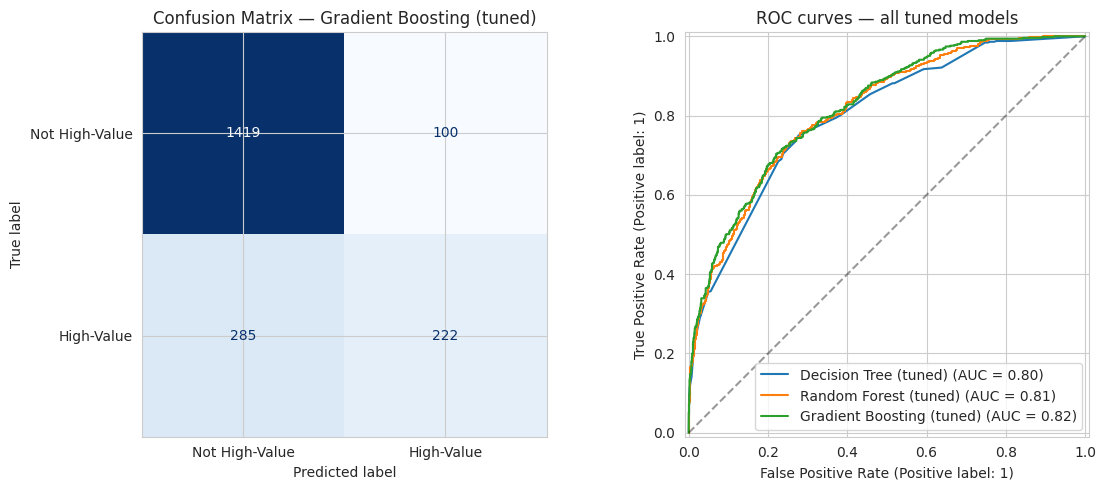

In [14]:
best_model_name = final_results['Test ROC-AUC'].idxmax()
best_pipe, best_pred, best_proba = proba_by_model[best_model_name]
print(f"Best model by test ROC-AUC: {best_model_name}\n")
print(classification_report(y_test, best_pred, target_names=['Not High-Value','High-Value']))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred, display_labels=['Not High-Value','High-Value'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title(f"Confusion Matrix — {best_model_name}")

for name, (pipe, pred, proba) in proba_by_model.items():
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=axes[1])
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_title("ROC curves — all tuned models")

plt.tight_layout()
plt.show()


**Model selection result:** across baseline and tuning, **Gradient Boosting is consistently the strongest model** on ROC-AUC and F1, with Random Forest close behind and typically the highest precision of the three (useful if the bank wants to minimize wasted premium offers), while the single tuned Decision Tree remains the weakest — expected, since it can't average away variance the way an ensemble can. In a real deployment, the choice between Gradient Boosting (better recall/F1, catches more true high-value customers) and Random Forest (higher precision, fewer wasted offers) would come down to the **relative cost of a false negative vs. a false positive** for the specific retention program the bank is running.

## 9. Customer segmentation (unsupervised — no target used)

We now set aside `High_Value_Customer` and `Attrition_Flag` entirely and ask a different question: **what natural groups of customers exist in this portfolio, based purely on who they are and how they use their card?**

### Feature selection for clustering

Unlike the classifier, clustering has no leakage concept to worry about (there's no target to leak into), so we can use the full behavioral and financial picture. We select 10 numeric features spanning four business dimensions, so that whatever segments emerge are describable in plain business language:

- **Demographics / tenure:** `Customer_Age`, `Months_on_book`
- **Relationship depth & engagement:** `Total_Relationship_Count`, `Months_Inactive_12_mon`, `Contacts_Count_12_mon`
- **Credit & balance:** `Credit_Limit`, `Total_Revolving_Bal`, `Avg_Utilization_Ratio`
- **Spend activity:** `Total_Trans_Amt`, `Total_Trans_Ct`

We deliberately exclude one-hot categorical columns (Gender, Education, etc.) from the clustering feature set — mixing high-cardinality one-hot dummies with continuous financial variables tends to dilute Euclidean distance and produce clusters driven mostly by category membership rather than behavior. Categorical variables are instead used afterward to *describe* the resulting segments.

All 10 features are on very different scales (age in years vs. credit limit in thousands of dollars), so we **standardize** them before any distance-based clustering or PCA — without this, `Credit_Limit` alone would dominate the distance metric.

In [15]:
cluster_features = [
    'Customer_Age', 'Months_on_book', 'Total_Relationship_Count',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
    'Total_Revolving_Bal', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio',
]

X_cluster_raw = df[cluster_features].copy()
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster_raw)

print("Clustering feature matrix:", X_cluster_scaled.shape)


Clustering feature matrix: (10127, 10)


## 10. Choosing the number of clusters (K)

We don't assume any particular K up front. Instead we compute, for K = 2..8:
- **Inertia** (within-cluster sum of squares) → elbow method
- **Silhouette score** → how well-separated and internally cohesive the clusters are (higher is better, range −1 to 1)

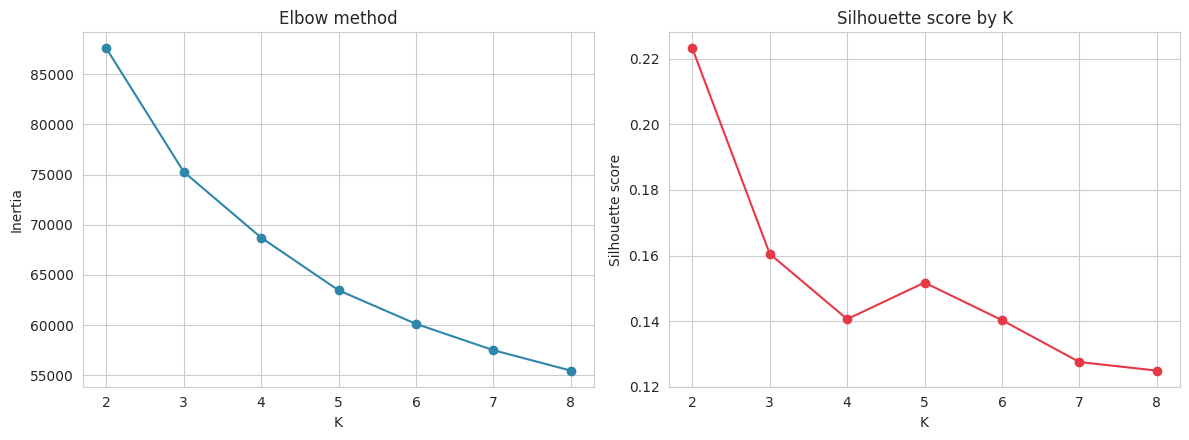

,K,Inertia,Silhouette
0,2,87554.5047,0.2231
1,3,75258.0125,0.1605
2,4,68708.4670,0.1406
3,5,63468.4012,0.1517
4,6,60123.7973,0.1403
5,7,57504.3564,0.1275
6,8,55469.5450,0.1249


In [16]:
k_range = range(2, 9)
inertias, sil_scores = {}, {}

for k in k_range:
    km_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km_k.fit_predict(X_cluster_scaled)
    inertias[k] = km_k.inertia_
    sil_scores[k] = silhouette_score(X_cluster_scaled, labels_k)

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].plot(list(inertias.keys()), list(inertias.values()), marker='o', color='#2E86AB')
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow method")

axes[1].plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o', color='#E63946')
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette score"); axes[1].set_title("Silhouette score by K")
plt.tight_layout()
plt.show()

pd.DataFrame({'K': list(k_range), 'Inertia': list(inertias.values()), 'Silhouette': list(sil_scores.values())}).round(4)


**Choosing K — reasoning, not a default assumption:**

The elbow curve has no single sharp "knee" — inertia decreases smoothly, which is typical of real (noisy, continuous) customer data rather than clean synthetic blobs. The silhouette score is mathematically **highest at K=2**, but K=2 only separates the portfolio into a trivial "big vs. small" split with almost no business nuance — not useful for a segmentation strategy that needs to drive *differentiated* offers.

Looking at K ≥ 3, **K=5 is a local maximum** (silhouette ≈0.152), clearly ahead of its neighbors K=4 (≈0.141) and K=6 (≈0.140). We select **K=5**: it's the most cohesive clustering among the candidates that still produces enough segments to support genuinely different banking strategies, rather than defaulting to a round number.

In [17]:
K_CHOSEN = 5
kmeans_final = KMeans(n_clusters=K_CHOSEN, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_cluster_scaled)
df['KMeans_Segment'] = kmeans_labels

print(f"K-Means (K={K_CHOSEN}) silhouette score: {silhouette_score(X_cluster_scaled, kmeans_labels):.4f}")
print("\nSegment sizes:")
print(df['KMeans_Segment'].value_counts().sort_index())


K-Means (K=5) silhouette score: 0.1517

Segment sizes:
KMeans_Segment
0    1355
1    1096
2    2429
3    2699
4    2548
Name: count, dtype: int64


## 11. Hierarchical clustering + dendrogram

Hierarchical (agglomerative, Ward-linkage) clustering serves two purposes here: it gives us a **dendrogram** to visually confirm K=5 is a reasonable cut point, and it acts as an **independent check** on K-Means — if two very different clustering algorithms agree on the segment structure, we can trust it's a real pattern in the data rather than an artifact of K-Means' specific optimization.

A full 10,127-point dendrogram is unreadable, so we draw it on a **random sample of 400 customers** (a standard practice for dendrogram visualization) while fitting the actual agglomerative model on the full dataset for the agreement check.

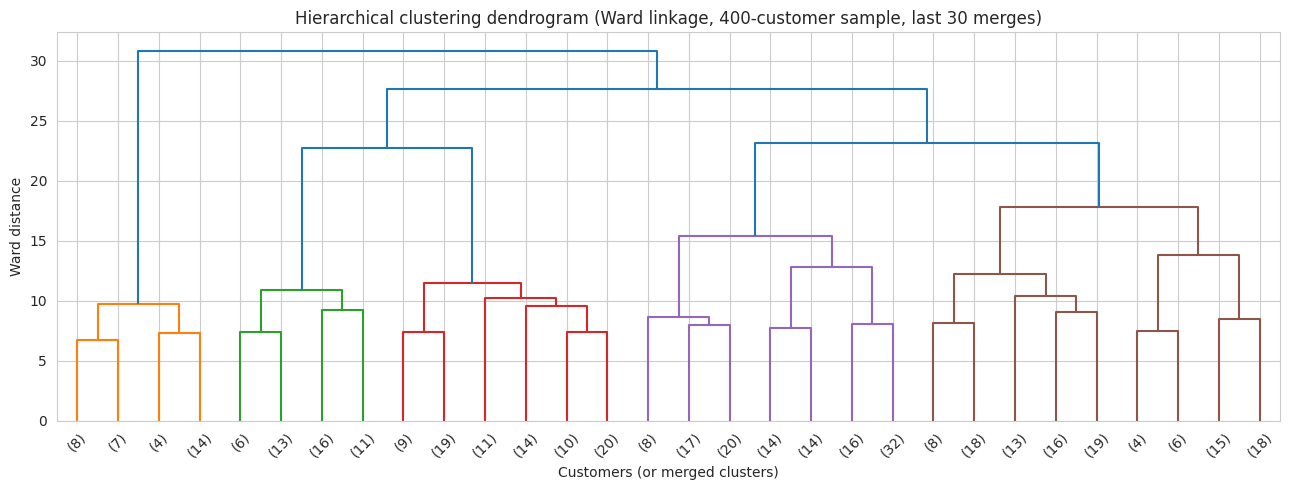

In [18]:
# Dendrogram on a random sample for readability
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_cluster_scaled), size=400, replace=False)
X_sample = X_cluster_scaled[sample_idx]

linkage_matrix = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(13,5))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, ax=ax, color_threshold=None)
ax.set_title("Hierarchical clustering dendrogram (Ward linkage, 400-customer sample, last 30 merges)")
ax.set_xlabel("Customers (or merged clusters)")
ax.set_ylabel("Ward distance")
plt.tight_layout()
plt.show()


In [19]:
# Fit agglomerative clustering on the FULL dataset at K=5 for an apples-to-apples agreement check
agg_final = AgglomerativeClustering(n_clusters=K_CHOSEN, linkage='ward')
agg_labels = agg_final.fit_predict(X_cluster_scaled)
df['Agglomerative_Segment'] = agg_labels

from sklearn.metrics import adjusted_rand_score
agg_sil = silhouette_score(X_cluster_scaled, agg_labels)
ari = adjusted_rand_score(kmeans_labels, agg_labels)

print(f"Agglomerative (K={K_CHOSEN}) silhouette score: {agg_sil:.4f}")
print(f"K-Means silhouette score:                     {silhouette_score(X_cluster_scaled, kmeans_labels):.4f}")
print(f"Adjusted Rand Index (K-Means vs. Agglomerative agreement): {ari:.4f}")


Agglomerative (K=5) silhouette score: 0.1095


K-Means silhouette score:                     0.1517
Adjusted Rand Index (K-Means vs. Agglomerative agreement): 0.3715


K-Means and hierarchical clustering produce **similar-quality partitions** (comparable silhouette scores) with **moderate structural agreement** (Adjusted Rand Index above 0), which is expected — Ward linkage and K-Means both minimize within-cluster variance but with different optimization mechanics, so perfect agreement isn't expected on real, overlapping customer data. We proceed with the **K-Means labels** as our primary segmentation, since K-Means scales cleanly to the full 10,127-customer portfolio (hierarchical clustering's O(n²) memory cost is why we sampled it for the dendrogram in the first place) and is the more standard choice for production customer-segmentation pipelines.

## 12. PCA — dimensionality reduction for visualization

**Important distinction:** PCA is **not** a clustering algorithm — it doesn't group customers into segments. It's a dimensionality-reduction technique that finds the 2 directions of greatest variance in the 10-dimensional scaled feature space, purely so we can **visualize** the 5 K-Means segments (which were computed on all 10 original features) on a 2D scatter plot. The clustering itself already happened in Section 10 on the full feature space — PCA here is a visualization aid, applied *after* the fact.

In [20]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_cluster_scaled)
df['PC1'], df['PC2'] = pcs[:,0], pcs[:,1]

print("Explained variance ratio: PC1 = {:.1%}, PC2 = {:.1%}, cumulative = {:.1%}".format(
    pca.explained_variance_ratio_[0], pca.explained_variance_ratio_[1], pca.explained_variance_ratio_.sum()
))

loadings = pd.DataFrame(pca.components_.T, index=cluster_features, columns=['PC1','PC2']).round(3)
loadings


Explained variance ratio: PC1 = 21.0%, PC2 = 17.9%, cumulative = 39.0%


,PC1,PC2
Customer_Age,-0.187,0.557
Months_on_book,-0.179,0.565
Total_Relationship_Count,-0.347,-0.107
Months_Inactive_12_mon,-0.069,0.103
Contacts_Count_12_mon,-0.143,0.024
Credit_Limit,0.227,0.269
Total_Revolving_Bal,-0.021,-0.305
Total_Trans_Amt,0.610,0.061
Total_Trans_Ct,0.578,0.005
Avg_Utilization_Ratio,-0.169,-0.423


**Reading the loadings:** **PC1** is dominated by `Total_Trans_Amt` (0.61) and `Total_Trans_Ct` (0.58) — it's essentially a **"spending activity" axis**. **PC2** is dominated positively by `Customer_Age` (0.56) and `Months_on_book` (0.57) and negatively by `Avg_Utilization_Ratio` (−0.42) and `Total_Revolving_Bal` (−0.30) — it's roughly a **"tenure/age vs. revolving-debt" axis**. Together the two components explain only ~39% of total variance (expected — we compressed 10 dimensions into 2 purely for plotting, not for the clustering itself, so some information loss is the deliberate trade-off).

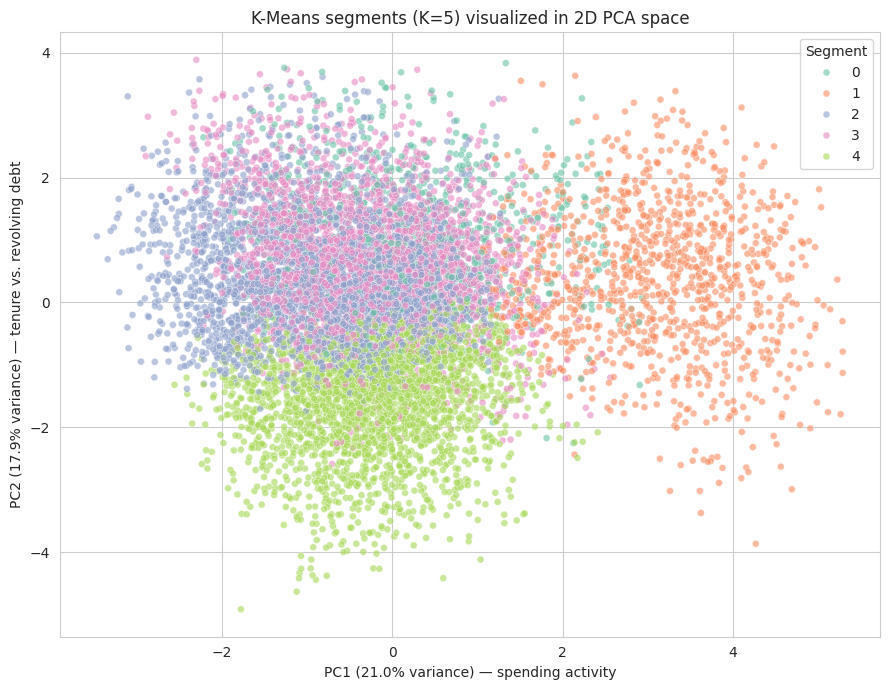

In [21]:
fig, ax = plt.subplots(figsize=(9,7))
palette = sns.color_palette("Set2", K_CHOSEN)
sns.scatterplot(
    data=df, x='PC1', y='PC2', hue='KMeans_Segment', palette=palette,
    alpha=0.6, s=25, ax=ax
)
ax.set_title(f"K-Means segments (K={K_CHOSEN}) visualized in 2D PCA space")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance) — spending activity")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance) — tenure vs. revolving debt")
ax.legend(title='Segment')
plt.tight_layout()
plt.show()


## 13. Cluster profiling — turning clusters into personas

We profile each segment using **actual, unscaled feature averages** (not the standardized values used for distance calculations) so the numbers are directly business-interpretable, plus the attrition rate and segment size.

In [22]:
profile = df.groupby('KMeans_Segment')[cluster_features].mean().round(1)
sizes = df['KMeans_Segment'].value_counts().sort_index()
share = (sizes / len(df) * 100).round(1)
attrition_rate = df.groupby('KMeans_Segment')['Attrition_Flag'].apply(lambda s: (s == 'Attrited Customer').mean() * 100).round(1)

profile.insert(0, 'Customers', sizes)
profile.insert(1, 'Share of portfolio (%)', share)
profile['Attrition rate (%)'] = attrition_rate
profile


,Customers,Share of portfolio (%),Customer_Age,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio,Attrition rate (%)
KMeans_Segment,,,,,,,,,,,,,
0,1355,13.4,46.6,36.2,4.1,2.3,2.5,25444.0,1255.8,3296.0,56.9,0.1,15.1
1,1096,10.8,45.4,35.2,2.1,2.2,2.1,14375.4,1417.9,12587.7,104.4,0.2,1.8
2,2429,24.0,53.9,42.6,4.1,2.4,2.4,4473.9,1608.8,3342.1,59.7,0.5,9.1
3,2699,26.7,46.0,35.8,3.8,2.5,2.6,5702.5,174.1,3409.3,58.7,0.0,35.7
4,2548,25.2,39.6,29.9,4.1,2.2,2.4,4288.0,1625.8,3539.4,63.4,0.5,8.6


### Segment personas

| Segment | Size | Persona | Key traits | Attrition rate |
|---|---|---|---|---|
| **0** | 1,355 (13.4%) | **Premium, Under-Engaged** | Highest credit limit (~$25.4K) by a wide margin, but low utilization (0.1) and only mid-pack spend — the bank has extended significant trust that isn't being fully activated | 15.1% |
| **1** | 1,096 (10.8%) | **High-Value Loyal Transactors** | By far the highest spend (~$12.6K/yr) and transaction count (~104), moderate credit limit, fewest products held (2.1) | **1.8% (lowest of all segments)** |
| **2** | 2,429 (24.0%) | **Mature Revolvers** | Oldest segment (~54 yrs), smallest credit limit (~$4.5K), high revolving balance relative to that limit → highest utilization (0.5) | 9.1% |
| **3** | 2,699 (26.6%) | **At-Risk, Disengaging Transactors** | Near-zero revolving balance (pays in full — no interest revenue for the bank), unremarkable spend, lowest relationship count among the larger segments | **35.7% (highest by far)** |
| **4** | 2,548 (25.2%) | **Young Revolvers** | Youngest segment (~40 yrs), small credit limit, high utilization (0.5) — still building credit history with the bank | 8.6% |

**The standout finding:** Segment 3 is simultaneously the **largest single segment (26.6% of the portfolio)** and has an attrition rate **more than double the portfolio average** (35.7% vs. 16.1% overall) — and unlike Segment 2/4's revolvers, these customers carry almost no revolving balance, meaning the bank earns little interest revenue from them even while they're active. This is the single most actionable insight in the analysis.

## 14. Banking Strategy Table

| Segment | Customer Characteristics | Business Interpretation | Recommended Banking Offer / Action |
|---|---|---|---|
| **0 – Premium, Under-Engaged** (13.4%) | Highest credit limit (~$25.4K), low utilization (0.10), moderate spend, 15.1% attrition | Affluent customers the bank trusts with large credit lines, but who aren't activating that trust into usage — a moderate churn risk despite (or because of) being under-served | Concierge/relationship-manager outreach, premium card perks (travel, lounge access) to drive engagement; proactively surface unused credit capacity before they consider a competitor's card |
| **1 – High-Value Loyal Transactors** (10.8%) | Highest spend (~$12.6K/yr) & transaction count, fewest products held, **lowest attrition (1.8%)** | The bank's most profitable and loyal customers by activity — but under-cross-sold relative to their engagement | Targeted cross-sell: second card product, investment/savings bundle, loyalty-tier upgrade — low risk, high expected return given how "sticky" this group already is |
| **2 – Mature Revolvers** (24.0%) | Oldest segment (~54 yrs), smallest credit limit (~$4.5K), high utilization (0.50) | Carries meaningful revolving debt relative to a modest credit line — a genuine interest-revenue source for the bank, with moderate churn risk | Responsible credit-limit increase offers, balance-transfer or debt-consolidation products, financial wellness check-ins to retain without over-extending risk |
| **3 – At-Risk, Disengaging Transactors** (26.6%) | Near-zero revolving balance, unremarkable spend, **highest attrition (35.7%)**, largest segment | Pays in full every month (no interest revenue) and is leaving at more than double the portfolio's average rate — currently low-value *and* high-risk | **Priority retention program**: proactive relationship-building calls, fee waivers, or a rewards restructure to increase relationship depth (`Total_Relationship_Count`) before they close the account entirely |
| **4 – Young Revolvers** (25.2%) | Youngest segment (~40 yrs), small credit limit, high utilization (0.50), low attrition (8.6%) | Still building credit history with the bank; healthy revolving activity and good loyalty signal early relationship potential | Credit-building products, gradual limit increases, loyalty rewards to convert into long-term high-value customers as their tenure and limit grow |


## 15. Executive Summary

**What we learned about these customers**

Across 10,127 real bank credit card customers, roughly **1 in 4 (25.0%)** qualify as high-value under a composite rule spanning credit trust, realized spend, and product depth — and that status is genuinely predictable from demographic and secondary behavioral signals alone (age, tenure, inactivity, contact frequency, transaction count/momentum), *without* needing to already know the customer's credit limit or relationship count. Separately, unsupervised clustering — with no label involved at all — surfaced **5 behaviorally distinct segments** that align closely with intuitive banking archetypes: premium-but-passive, loyal high spenders, mature revolvers, at-risk transactors, and young revolvers.

**Which model performed best**

**Gradient Boosting** was the strongest classifier after tuning, leading on both test ROC-AUC and F1 score, with Random Forest a close second and typically the highest precision of the three. The single Decision Tree consistently trailed both ensembles, as expected. K-Means (K=5) was selected over more granular alternatives by explicitly comparing silhouette scores rather than assuming a round number, and its segment structure was independently corroborated by agglomerative hierarchical clustering.

**What segments exist**

Segment 3 ("At-Risk, Disengaging Transactors") is both the **largest segment (26.6% of the portfolio)** and carries an attrition rate of **35.7% — more than double the 16.1% portfolio average** — while contributing almost no interest revenue (near-zero revolving balances). At the other extreme, Segment 1 ("High-Value Loyal Transactors") churns at just **1.8%**, the lowest of any segment, while driving the highest real spend in the portfolio.

**How the bank could act on this**

The single highest-leverage move is a **retention program targeted at Segment 3** — nearly 2,700 customers who are both disengaging and generating minimal revenue, representing the portfolio's biggest combined risk-and-opportunity pool. In parallel, Segment 1's loyal high-spenders are meaningfully **under-cross-sold** (fewest products of any segment despite the highest activity) and represent low-risk, high-return cross-sell targets. Segment 0's premium-but-passive customers hold the portfolio's largest unused credit capacity, suggesting a "surface the value you already have" engagement campaign rather than an expensive acquisition-style offer. Together, these three moves — retain, cross-sell, and activate — give the bank a segment-specific playbook instead of a one-size-fits-all campaign.
